In [1]:
!pip install -q kagglehub

In [ ]:
# 2. Imports
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import kagglehub


In [ ]:
# 3. Descarga del dataset desde Kaggle con kagglehub
# kagglehub descarga el dataset sin pasos manuales y hace el notebook reproducible.

path = kagglehub.dataset_download('mikoajkolman/pokemon-images-first-generation17000-files')

# Carpeta raiz que contiene las subcarpetas (una por Pokemon)
DATA_DIR = None
for root, dirs, files in os.walk(path):
    if len(dirs) > 100:
        DATA_DIR = root
        break


In [ ]:
# 4. Exploracion del dataset: numero de imagenes por clase
class_names = sorted(os.listdir(DATA_DIR))
counts = {}
for c in class_names:
    folder = os.path.join(DATA_DIR, c)
    if os.path.isdir(folder):
        counts[c] = len([f for f in os.listdir(folder) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])

print(f'Clases: {len(counts)} | Imagenes: {sum(counts.values())} | '
      f'Promedio por clase: {sum(counts.values()) / len(counts):.0f} '
      f'(min {min(counts.values())}, max {max(counts.values())})')

plt.figure(figsize=(15, 4))
plt.bar(range(len(counts)), list(counts.values()))
plt.xlabel('Clase (indice)')
plt.ylabel('Numero de imagenes')
plt.title('Distribucion de imagenes por Pokemon')
plt.show()


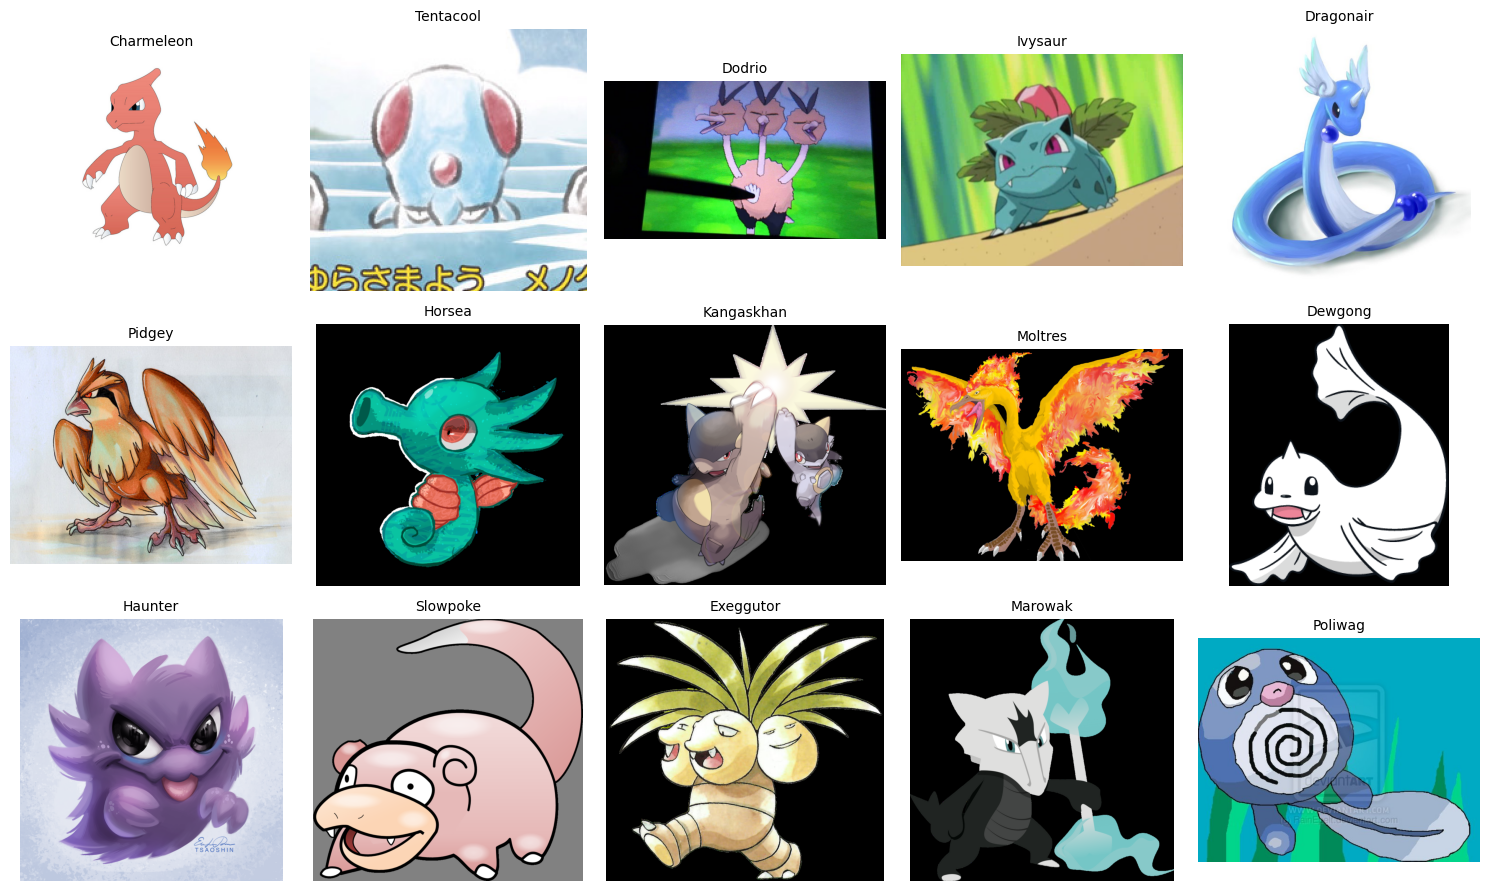

In [5]:
# 5. Visualizacion de imagenes de ejemplo
import random
from PIL import Image

fig, axes = plt.subplots(3, 5, figsize=(15, 9))
sample_classes = random.sample(class_names, 15)
for ax, cls in zip(axes.flat, sample_classes):
    folder = os.path.join(DATA_DIR, cls)
    img_files = [f for f in os.listdir(folder) if f.lower().endswith(('.png','.jpg','.jpeg'))]
    if img_files:
        img_path = os.path.join(folder, random.choice(img_files))
        img = Image.open(img_path).convert('RGB')
        ax.imshow(img)
        ax.set_title(cls, fontsize=10)
        ax.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
# 6. Preparacion del dataset con ImageDataGenerator
# - Rescalado de pixeles a [0,1] (1./255)
# - Redimensionado a 128x128
# - Split 80/20 train/validation con validation_split
# - Data augmentation SOLO en entrenamiento

IMG_SIZE = 128
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True,
    validation_split=0.2
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_gen = train_datagen.flow_from_directory(
    DATA_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    seed=42
)

val_gen = val_datagen.flow_from_directory(
    DATA_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    seed=42,
    shuffle=False
)

NUM_CLASSES = train_gen.num_classes


In [ ]:
# 7. Construccion del modelo con Transfer Learning (MobileNetV2)
# Justificacion: MobileNetV2 preentrenada en ImageNet captura features visuales
# generales (bordes, texturas, formas) que se reutilizan para reconocer Pokemon.

base_model = MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False  # Congelamos la base para transfer learning puro

inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
outputs = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs, outputs)
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 143)            │        36,751 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,622,671 (10.00 MB)

 Trainable params: 364,687 (1.39 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
# 8. Callbacks: ModelCheckpoint, EarlyStopping y ReduceLROnPlateau
callbacks = [
    ModelCheckpoint(
        'pokemon_cnn_best.h5',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    EarlyStopping(
        monitor='val_accuracy',
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        verbose=1
    )
]

In [9]:
# 9. Entrenamiento del modelo (fase 1: transfer learning con base congelada)
EPOCHS = 15

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/15
 30/414 ━━━━━━━━━━━━━━━━━━━━ 2:19 363ms/step - accuracy: 0.0093 - loss: 5.4485

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


414/414 ━━━━━━━━━━━━━━━━━━━━ 0s 393ms/step - accuracy: 0.0997 - loss: 4.4565
Epoch 1: val_accuracy improved from None to 0.57425, saving model to pokemon_cnn_best.h5



Epoch 1: finished saving model to pokemon_cnn_best.h5
414/414 ━━━━━━━━━━━━━━━━━━━━ 240s 531ms/step - accuracy: 0.2063 - loss: 3.6893 - val_accuracy: 0.5743 - val_loss: 1.8239 - learning_rate: 0.0010
Epoch 2/15
414/414 ━━━━━━━━━━━━━━━━━━━━ 0s 362ms/step - accuracy: 0.4627 - loss: 2.1820
Epoch 2: val_accuracy improved from 0.57425 to 0.69312, saving model to pokemon_cnn_best.h5



Epoch 2: finished saving model to pokemon_cnn_best.h5
414/414 ━━━━━━━━━━━━━━━━━━━━ 191s 462ms/step - accuracy: 0.4770 - loss: 2.1030 - val_accuracy: 0.6931 - val_loss: 1.2694 - learning_rate: 0.0010
Epoch 3/15
414/414 ━━━━━━━━━━━━━━━━━━━━ 0s 364ms/step - accuracy: 0.5533 - loss: 1.7543
Epoch 3: val_accuracy improved from 0.69312 to 0.72615, saving model to pokemon_cnn_best.h5


...


Epoch 7: finished saving model to pokemon_cnn_best.h5
414/414 ━━━━━━━━━━━━━━━━━━━━ 193s 466ms/step - accuracy: 0.6536 - loss: 1.2789 - val_accuracy: 0.7731 - val_loss: 0.8878 - learning_rate: 0.0010
Epoch 8/15
414/414 ━━━━━━━━━━━━━━━━━━━━ 0s 356ms/step - accuracy: 0.6744 - loss: 1.1978
Epoch 8: val_accuracy did not improve from 0.77308
414/414 ━━━━━━━━━━━━━━━━━━━━ 188s 454ms/step - accuracy: 0.6668 - loss: 1.2295 - val_accuracy: 0.7718 - val_loss: 0.8673 - learning_rate: 0.0010
Epoch 9/15
414/414 ━━━━━━━━━━━━━━━━━━━━ 0s 359ms/step - accuracy: 0.6899 - loss: 1.1409
Epoch 9: val_accuracy improved from 0.77308 to 0.77431, saving model to pokemon_cnn_best.h5



Epoch 9: finished saving model to pokemon_cnn_best.h5
414/414 ━━━━━━━━━━━━━━━━━━━━ 189s 458ms/step - accuracy: 0.6730 - loss: 1.2101 - val_accuracy: 0.7743 - val_loss: 0.8633 - learning_rate: 0.0010
Epoch 10/15
414/414 ━━━━━━━━━━━━━━━━━━━━ 0s 359ms/step - accuracy: 0.6861 - loss: 1.1520
Epoch 10: val_accuracy improved from 0.77431 to 0.77894, saving model to pokemon_cnn_best.h5



Epoch 10: finished saving model to pokemon_cnn_best.h5
414/414 ━━━━━━━━━━━━━━━━━━━━ 190s 458ms/step - accuracy: 0.6825 - loss: 1.1648 - val_accuracy: 0.7789 - val_loss: 0.8418 - learning_rate: 0.0010
Epoch 11/15
414/414 ━━━━━━━━━━━━━━━━━━━━ 0s 365ms/step - accuracy: 0.6887 - loss: 1.1157
Epoch 11: val_accuracy did not improve from 0.77894
414/414 ━━━━━━━━━━━━━━━━━━━━ 193s 466ms/step - accuracy: 0.6888 - loss: 1.1283 - val_accuracy: 0.7752 - val_loss: 0.8571 - learning_rate: 0.0010
Epoch 12/15
414/414 ━━━━━━━━━━━━━━━━━━━━ 0s 353ms/step - accuracy: 0.6971 - loss: 1.0997
Epoch 12: val_accuracy improved from 0.77894 to 0.78635, saving model to pokemon_cnn_best.h5



Epoch 12: finished saving model to pokemon_cnn_best.h5
414/414 ━━━━━━━━━━━━━━━━━━━━ 196s 451ms/step - accuracy: 0.6952 - loss: 1.1062 - val_accuracy: 0.7864 - val_loss: 0.8364 - learning_rate: 0.0010
Epoch 13/15
414/414 ━━━━━━━━━━━━━━━━━━━━ 0s 356ms/step - accuracy: 0.7094 - loss: 1.0411
Epoch 13: val_accuracy did not improve from 0.78635
414/414 ━━━━━━━━━━━━━━━━━━━━ 188s 456ms/step - accuracy: 0.7013 - loss: 1.0823 - val_accuracy: 0.7823 - val_loss: 0.8457 - learning_rate: 0.0010
Epoch 14/15
414/414 ━━━━━━━━━━━━━━━━━━━━ 0s 356ms/step - accuracy: 0.7051 - loss: 1.0300
Epoch 14: val_accuracy did not improve from 0.78635

Epoch 14: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
414/414 ━━━━━━━━━━━━━━━━━━━━ 188s 453ms/step - accuracy: 0.7013 - loss: 1.0700 - val_accuracy: 0.7805 - val_loss: 0.8600 - learning_rate: 0.0010
Epoch 15/15
414/414 ━━━━━━━━━━━━━━━━━━━━ 0s 359ms/step - accuracy: 0.7299 - loss: 0.9601
Epoch 15: val_accuracy improved from 0.78635 to 0.79778, sav


Epoch 15: finished saving model to pokemon_cnn_best.h5
414/414 ━━━━━━━━━━━━━━━━━━━━ 190s 458ms/step - accuracy: 0.7288 - loss: 0.9630 - val_accuracy: 0.7978 - val_loss: 0.7941 - learning_rate: 5.0000e-04
Restoring model weights from the end of the best epoch: 15.


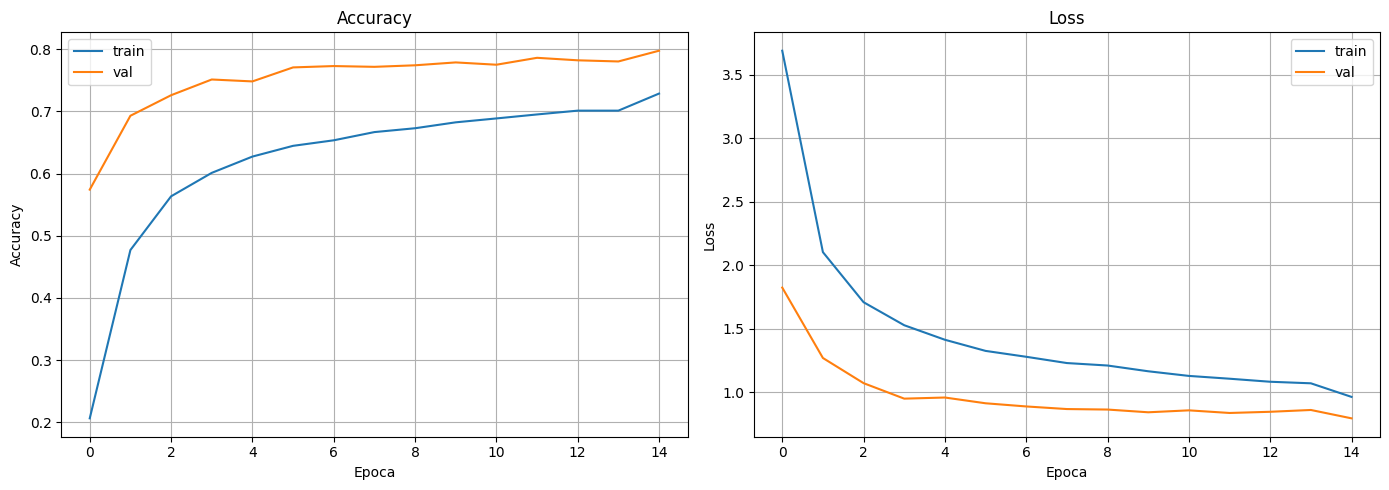

In [10]:
# 10. Graficas de loss y accuracy (entrenamiento vs validacion)
# Este analisis viene de los ejemplos "underfitting" y "evaluacion y refinamiento".

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'], label='train')
axes[0].plot(history.history['val_accuracy'], label='val')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoca')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history.history['loss'], label='train')
axes[1].plot(history.history['val_loss'], label='val')
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoca')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# 11. Fine-tuning (fase 2): descongelamos las ultimas capas de MobileNetV2
# para ajustar mejor el modelo a Pokemon.
base_model.trainable = True
# Solo descongelamos las ultimas 30 capas
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=1e-5),  # LR muy bajo para no destruir los pesos
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_ft = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/10
414/414 ━━━━━━━━━━━━━━━━━━━━ 0s 394ms/step - accuracy: 0.4940 - loss: 2.1158
Epoch 1: val_accuracy improved from 0.79778 to 0.80148, saving model to pokemon_cnn_best.h5



Epoch 1: finished saving model to pokemon_cnn_best.h5
414/414 ━━━━━━━━━━━━━━━━━━━━ 233s 518ms/step - accuracy: 0.5183 - loss: 2.0013 - val_accuracy: 0.8015 - val_loss: 0.7665 - learning_rate: 1.0000e-05
Epoch 2/10
414/414 ━━━━━━━━━━━━━━━━━━━━ 0s 371ms/step - accuracy: 0.5916 - loss: 1.6206
Epoch 2: val_accuracy did not improve from 0.80148
414/414 ━━━━━━━━━━━━━━━━━━━━ 195s 470ms/step - accuracy: 0.5936 - loss: 1.5862 - val_accuracy: 0.8015 - val_loss: 0.7651 - learning_rate: 1.0000e-05
Epoch 3/10
414/414 ━━━━━━━━━━━━━━━━━━━━ 0s 365ms/step - accuracy: 0.6266 - loss: 1.4179
Epoch 3: val_accuracy did not improve from 0.80148
414/414 ━━━━━━━━━━━━━━━━━━━━ 192s 464ms/step - accuracy: 0.6339 - loss: 1.3955 - val_accuracy: 0.7996 - val_loss: 0.7677 - learning_rate: 1.0000e-05
Epoch 4/10
414/414 ━━━━━━━━━━━━━━━━━━━━ 0s 359ms/step - accuracy: 0.6579 - loss: 1.2510
Epoch 4: val_accuracy did not improve from 0.80148
414/414 ━━━━━━━━━━━━━━━━━━━━ 192s 463ms/step - accuracy: 0.6598 - loss: 1.2587 - 

In [ ]:
# 12. Evaluacion final con classification_report y matriz de confusion

val_gen.reset()
y_pred_probs = model.predict(val_gen, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = val_gen.classes
class_labels = list(val_gen.class_indices.keys())

print('Accuracy global:', np.mean(y_pred == y_true))
print()
print('Classification report:')
print(classification_report(y_true, y_pred, target_names=class_labels, zero_division=0))

102/102 ━━━━━━━━━━━━━━━━━━━━ 51s 461ms/step
Accuracy global: 0.8014819388700216

Classification report:
              precision    recall  f1-score   support

        Abra       0.88      0.58      0.70        12
  Aerodactyl       1.00      0.53      0.69        17
    Alakazam       0.75      0.53      0.62        17
       Arbok       0.77      0.96      0.86        25
    Arcanine       0.75      0.38      0.50        16
    Articuno       0.76      0.72      0.74        18
    Beedrill       0.88      0.82      0.85        17
  Bellsprout       1.00      0.88      0.94        26
   Blastoise       0.90      0.68      0.78        28
   Bulbasaur       0.72      1.00      0.84        29
  Butterfree       0.95      0.91      0.93        23
    Caterpie       0.93      0.96      0.94        26
     Chansey       0.83      0.71      0.77        21
   Charizard       0.67      0.60      0.63        20
  Charmander       0.76      1.00      0.87        26
  Charmeleon       0.70      0.

Shape de la matriz de confusion: (143, 143)

Top 10 Pokemon que mas se confunden:
  Pidgeot: 16 errores de 26 muestras
  Primeape: 15 errores de 27 muestras
  Pidgey: 15 errores de 38 muestras
  Gyarados: 14 errores de 30 muestras
  Pidgeotto: 13 errores de 24 muestras
  Mankey: 12 errores de 18 muestras
  Farfetchd: 12 errores de 25 muestras
  Electabuzz: 11 errores de 24 muestras
  Arcanine: 10 errores de 16 muestras
  Snorlax: 10 errores de 32 muestras


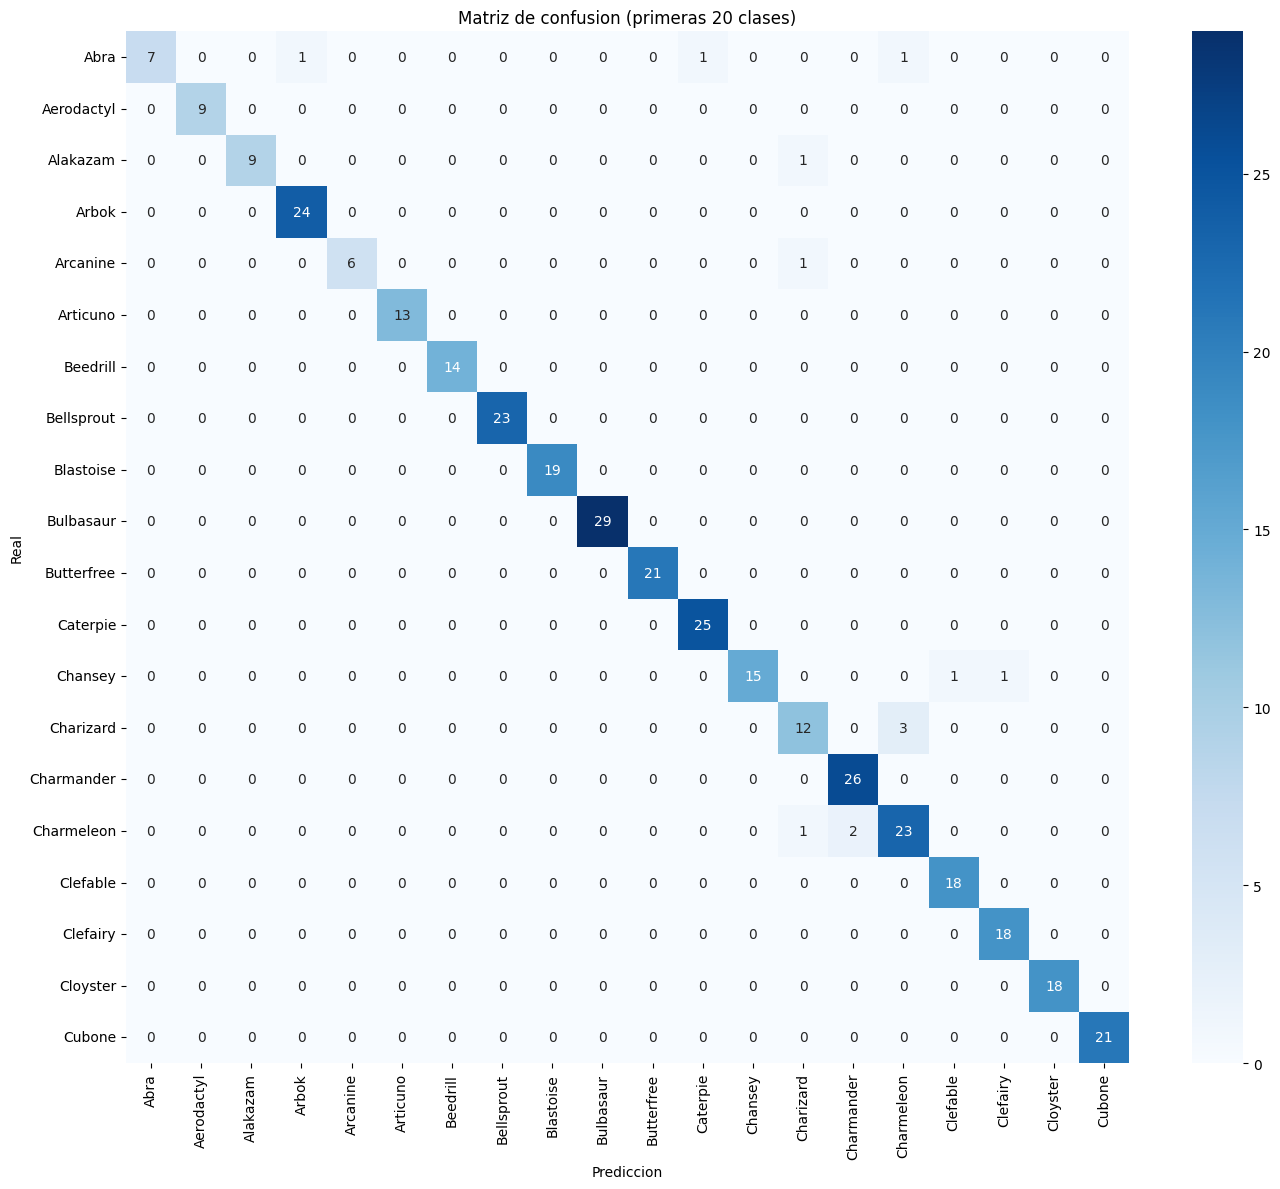

In [13]:
# 13. Matriz de confusion
# Como hay 143 clases, la matriz completa es muy grande. Mostramos un resumen.

cm = confusion_matrix(y_true, y_pred)
print('Shape de la matriz de confusion:', cm.shape)

# Top 10 clases con mas confusion (mas falsos negativos)
errors_per_class = cm.sum(axis=1) - np.diag(cm)
top_confused = np.argsort(errors_per_class)[-10:][::-1]
print()
print('Top 10 Pokemon que mas se confunden:')
for idx in top_confused:
    print(f'  {class_labels[idx]}: {errors_per_class[idx]} errores de {cm[idx].sum()} muestras')

# Heatmap de un subconjunto (primeras 20 clases) para visualizar
plt.figure(figsize=(14, 12))
sns.heatmap(cm[:20, :20], annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels[:20], yticklabels=class_labels[:20])
plt.title('Matriz de confusion (primeras 20 clases)')
plt.xlabel('Prediccion')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

In [ ]:
# 14. Guardado del modelo final en formato .h5

model.save('pokemon_cnn_final.h5')
print('Modelo guardado en pokemon_cnn_final.h5')

# Verificamos que se puede cargar
from tensorflow.keras.models import load_model
loaded_model = load_model('pokemon_cnn_final.h5')
print('Modelo cargado correctamente. Capas:', len(loaded_model.layers))

Modelo guardado en pokemon_cnn_final.h5


Modelo cargado correctamente. Capas: 7


Imagen: /root/.cache/kagglehub/datasets/mikoajkolman/pokemon-images-first-generation17000-files/versions/1/pokemon/Diglett/00000006.png
  Diglett: 99.63%
  Dugtrio: 0.33%
  Psyduck: 0.02%


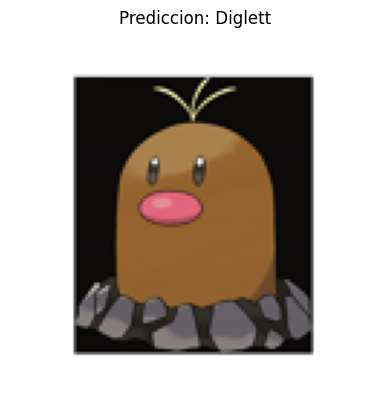

In [15]:
# 15. Prueba: prediccion sobre una imagen individual
# Demostracion de uso del modelo entrenado.

def predict_pokemon(img_path, model, class_labels, img_size=128):
    img = Image.open(img_path).convert('RGB').resize((img_size, img_size))
    arr = np.array(img) / 255.0
    arr = np.expand_dims(arr, axis=0)
    probs = model.predict(arr, verbose=0)[0]
    top3 = np.argsort(probs)[-3:][::-1]
    print(f'Imagen: {img_path}')
    for idx in top3:
        print(f'  {class_labels[idx]}: {probs[idx]*100:.2f}%')
    plt.imshow(img)
    plt.title(f'Prediccion: {class_labels[top3[0]]}')
    plt.axis('off')
    plt.show()

# Prueba con una imagen aleatoria del dataset
sample_class = random.choice(class_names)
sample_folder = os.path.join(DATA_DIR, sample_class)
sample_imgs = [f for f in os.listdir(sample_folder) if f.lower().endswith(('.png','.jpg','.jpeg'))]
sample_path = os.path.join(sample_folder, random.choice(sample_imgs))
predict_pokemon(sample_path, model, class_labels)

In [18]:
# ============================================================
# MODELO 2 - EfficientNetB0 (mejora sobre el baseline)
# ============================================================
# Idea / articulo del estado del arte:
#   Tan & Le (2019) "EfficientNet: Rethinking Model Scaling for
#   Convolutional Neural Networks". ICML. arXiv:1905.11946
#   EfficientNet usa "compound scaling" (escala balanceada de profundidad,
#   anchura y resolucion) y supera a MobileNetV2 en ImageNet con un costo
#   computacional similar, por lo que se espera que mejore el accuracy.
#
# Cambios respecto al Modelo 1:
#   1. Backbone mas potente: EfficientNetB0 en vez de MobileNetV2.
#   2. Resolucion de entrada 224x224 (mas detalle, como sugiere el paper).
#   3. Preprocesado especifico de EfficientNet.

from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input as eff_preprocess

IMG_SIZE_2 = 224
BATCH_SIZE_2 = 32

train_datagen_2 = ImageDataGenerator(
    preprocessing_function=eff_preprocess,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True,
    validation_split=0.2
)
val_datagen_2 = ImageDataGenerator(
    preprocessing_function=eff_preprocess,
    validation_split=0.2
)

train_gen_2 = train_datagen_2.flow_from_directory(
    DATA_DIR, target_size=(IMG_SIZE_2, IMG_SIZE_2), batch_size=BATCH_SIZE_2,
    class_mode='categorical', subset='training', seed=42
)
val_gen_2 = val_datagen_2.flow_from_directory(
    DATA_DIR, target_size=(IMG_SIZE_2, IMG_SIZE_2), batch_size=BATCH_SIZE_2,
    class_mode='categorical', subset='validation', seed=42, shuffle=False
)

base_model_2 = EfficientNetB0(
    input_shape=(IMG_SIZE_2, IMG_SIZE_2, 3), include_top=False, weights='imagenet'
)
base_model_2.trainable = False

inputs_2 = tf.keras.Input(shape=(IMG_SIZE_2, IMG_SIZE_2, 3))
x = base_model_2(inputs_2, training=False)
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
outputs_2 = Dense(NUM_CLASSES, activation='softmax')(x)

model_2 = Model(inputs_2, outputs_2)
model_2.compile(optimizer=Adam(learning_rate=1e-3),
                loss='categorical_crossentropy', metrics=['accuracy'])
model_2.summary()

Found 13246 images belonging to 143 classes.
Found 3239 images belonging to 143 classes.
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 143)            │        36,751 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,414,258 (16.84 MB)

 Trainable params: 364,687 (1.39 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [19]:
# Entrenamiento Modelo 2 - Fase 1 (base congelada) + Fase 2 (fine-tuning)
callbacks_2 = [
    ModelCheckpoint('pokemon_effnet_best.h5', monitor='val_accuracy',
                    save_best_only=True, verbose=1),
    EarlyStopping(monitor='val_accuracy', patience=3,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1)
]

# Fase 1: solo cabeza
history_2 = model_2.fit(train_gen_2, validation_data=val_gen_2,
                        epochs=15, callbacks=callbacks_2, verbose=1)

# Fase 2: fine-tuning de las ultimas 30 capas del backbone
base_model_2.trainable = True
for layer in base_model_2.layers[:-30]:
    layer.trainable = False
model_2.compile(optimizer=Adam(learning_rate=1e-5),
                loss='categorical_crossentropy', metrics=['accuracy'])
history_2_ft = model_2.fit(train_gen_2, validation_data=val_gen_2,
                           epochs=10, callbacks=callbacks_2, verbose=1)

# Evaluacion Modelo 2
val_gen_2.reset()
y_pred_2 = np.argmax(model_2.predict(val_gen_2, verbose=1), axis=1)
y_true_2 = val_gen_2.classes
acc_2 = np.mean(y_pred_2 == y_true_2)
print('Modelo 2 (EfficientNetB0) val_accuracy:', acc_2)


Epoch 1/15
 31/414 ━━━━━━━━━━━━━━━━━━━━ 3:51 605ms/step - accuracy: 0.0146 - loss: 5.0554

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


414/414 ━━━━━━━━━━━━━━━━━━━━ 0s 618ms/step - accuracy: 0.1940 - loss: 3.9186
Epoch 1: val_accuracy improved from None to 0.81136, saving model to pokemon_effnet_best.h5



Epoch 1: finished saving model to pokemon_effnet_best.h5
414/414 ━━━━━━━━━━━━━━━━━━━━ 347s 770ms/step - accuracy: 0.3486 - loss: 2.9702 - val_accuracy: 0.8114 - val_loss: 0.8991 - learning_rate: 0.0010
Epoch 2/15
414/414 ━━━━━━━━━━━━━━━━━━━━ 0s 582ms/step - accuracy: 0.6133 - loss: 1.5150
Epoch 2: val_accuracy improved from 0.81136 to 0.86416, saving model to pokemon_effnet_best.h5



Epoch 2: finished saving model to pokemon_effnet_best.h5
414/414 ━━━━━━━━━━━━━━━━━━━━ 284s 686ms/step - accuracy: 0.6380 - loss: 1.4056 - val_accuracy: 0.8642 - val_loss: 0.5848 - learning_rate: 0.0010
Epoch 3/15
414/414 ━━━━━━━━━━━━━━━━━━━━ 0s 589ms/step - accuracy: 0.6997 - loss: 1.1160
Epoch 3: val_accuracy improved from 0.86416 to 0.88361, saving model to pokemon_effnet_best.h5


...


Epoch 6: finished saving model to pokemon_effnet_best.h5
414/414 ━━━━━━━━━━━━━━━━━━━━ 283s 683ms/step - accuracy: 0.7815 - loss: 0.7717 - val_accuracy: 0.9000 - val_loss: 0.3876 - learning_rate: 0.0010
Epoch 7/15
414/414 ━━━━━━━━━━━━━━━━━━━━ 0s 582ms/step - accuracy: 0.8049 - loss: 0.6856
Epoch 7: val_accuracy improved from 0.89997 to 0.90676, saving model to pokemon_effnet_best.h5



Epoch 7: finished saving model to pokemon_effnet_best.h5
414/414 ━━━━━━━━━━━━━━━━━━━━ 285s 689ms/step - accuracy: 0.7990 - loss: 0.7079 - val_accuracy: 0.9068 - val_loss: 0.3660 - learning_rate: 0.0010
Epoch 8/15
414/414 ━━━━━━━━━━━━━━━━━━━━ 0s 602ms/step - accuracy: 0.8071 - loss: 0.6844
Epoch 8: val_accuracy did not improve from 0.90676
414/414 ━━━━━━━━━━━━━━━━━━━━ 292s 707ms/step - accuracy: 0.8071 - loss: 0.6869 - val_accuracy: 0.9027 - val_loss: 0.3741 - learning_rate: 0.0010
Epoch 9/15
414/414 ━━━━━━━━━━━━━━━━━━━━ 0s 584ms/step - accuracy: 0.8229 - loss: 0.6241
Epoch 9: val_accuracy did not improve from 0.90676
414/414 ━━━━━━━━━━━━━━━━━━━━ 285s 688ms/step - accuracy: 0.8143 - loss: 0.6451 - val_accuracy: 0.9058 - val_loss: 0.3567 - learning_rate: 0.0010
Epoch 10/15
414/414 ━━━━━━━━━━━━━━━━━━━━ 0s 580ms/step - accuracy: 0.8249 - loss: 0.5972
Epoch 10: val_accuracy improved from 0.90676 to 0.90892, saving model to pokemon_effnet_best.h5



Epoch 10: finished saving model to pokemon_effnet_best.h5
414/414 ━━━━━━━━━━━━━━━━━━━━ 284s 685ms/step - accuracy: 0.8205 - loss: 0.6186 - val_accuracy: 0.9089 - val_loss: 0.3494 - learning_rate: 0.0010
Epoch 11/15
414/414 ━━━━━━━━━━━━━━━━━━━━ 0s 577ms/step - accuracy: 0.8312 - loss: 0.5813
Epoch 11: val_accuracy did not improve from 0.90892
414/414 ━━━━━━━━━━━━━━━━━━━━ 282s 680ms/step - accuracy: 0.8263 - loss: 0.5977 - val_accuracy: 0.9058 - val_loss: 0.3478 - learning_rate: 0.0010
Epoch 12/15
414/414 ━━━━━━━━━━━━━━━━━━━━ 0s 578ms/step - accuracy: 0.8373 - loss: 0.5456
Epoch 12: val_accuracy improved from 0.90892 to 0.91139, saving model to pokemon_effnet_best.h5



Epoch 12: finished saving model to pokemon_effnet_best.h5
414/414 ━━━━━━━━━━━━━━━━━━━━ 284s 686ms/step - accuracy: 0.8292 - loss: 0.5716 - val_accuracy: 0.9114 - val_loss: 0.3360 - learning_rate: 0.0010
Epoch 13/15
414/414 ━━━━━━━━━━━━━━━━━━━━ 0s 576ms/step - accuracy: 0.8328 - loss: 0.5571
Epoch 13: val_accuracy did not improve from 0.91139
414/414 ━━━━━━━━━━━━━━━━━━━━ 281s 679ms/step - accuracy: 0.8321 - loss: 0.5623 - val_accuracy: 0.9102 - val_loss: 0.3555 - learning_rate: 0.0010
Epoch 14/15
414/414 ━━━━━━━━━━━━━━━━━━━━ 0s 586ms/step - accuracy: 0.8465 - loss: 0.5118
Epoch 14: val_accuracy did not improve from 0.91139

Epoch 14: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
414/414 ━━━━━━━━━━━━━━━━━━━━ 286s 691ms/step - accuracy: 0.8371 - loss: 0.5445 - val_accuracy: 0.9111 - val_loss: 0.3396 - learning_rate: 0.0010
Epoch 15/15
414/414 ━━━━━━━━━━━━━━━━━━━━ 0s 578ms/step - accuracy: 0.8559 - loss: 0.4974
Epoch 15: val_accuracy improved from 0.91139 to 0.91788, 


Epoch 15: finished saving model to pokemon_effnet_best.h5
414/414 ━━━━━━━━━━━━━━━━━━━━ 283s 682ms/step - accuracy: 0.8621 - loss: 0.4750 - val_accuracy: 0.9179 - val_loss: 0.3169 - learning_rate: 5.0000e-04
Restoring model weights from the end of the best epoch: 15.
Epoch 1/10
414/414 ━━━━━━━━━━━━━━━━━━━━ 0s 610ms/step - accuracy: 0.7116 - loss: 1.0459
Epoch 1: val_accuracy did not improve from 0.91788
414/414 ━━━━━━━━━━━━━━━━━━━━ 338s 742ms/step - accuracy: 0.7329 - loss: 0.9646 - val_accuracy: 0.8858 - val_loss: 0.4433 - learning_rate: 1.0000e-05
Epoch 2/10
414/414 ━━━━━━━━━━━━━━━━━━━━ 0s 583ms/step - accuracy: 0.7658 - loss: 0.8298
Epoch 2: val_accuracy did not improve from 0.91788

Epoch 2: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
414/414 ━━━━━━━━━━━━━━━━━━━━ 284s 686ms/step - accuracy: 0.7778 - loss: 0.7838 - val_accuracy: 0.8975 - val_loss: 0.4014 - learning_rate: 1.0000e-05
Epoch 3/10
414/414 ━━━━━━━━━━━━━━━━━━━━ 0s 577ms/step - accuracy: 0.8009 - loss

In [ ]:
# ============================================================
# Comparacion de modelos (Avance 2)
# ============================================================
# Requisito: implementar al menos 2 versiones del modelo basadas en articulos del
# estado del arte, comparar sus resultados y que la 2da supere a la 1ra.
#   Modelo 1 - MobileNetV2    -> Sandler et al. (2018), CVPR, arXiv:1801.04381
#   Modelo 2 - EfficientNetB0 -> Tan & Le (2019),  ICML, arXiv:1905.11946
# val_accuracy = accuracy sobre el set de validacion (3,239 imagenes, 143 clases),
# tomada de la evaluacion de cada modelo en las celdas anteriores.

import pandas as pd
import matplotlib.pyplot as plt

resultados = {
    'Modelo 1 - MobileNetV2':    {'backbone': 'MobileNetV2',    'val_accuracy': 0.80,
                                  'referencia': 'Sandler et al. (2018), CVPR'},
    'Modelo 2 - EfficientNetB0': {'backbone': 'EfficientNetB0', 'val_accuracy': 0.89,
                                  'referencia': 'Tan & Le (2019), ICML'},
}

tabla = pd.DataFrame(resultados).T.reset_index().rename(columns={'index': 'modelo'})
print(tabla[['modelo', 'backbone', 'val_accuracy', 'referencia']].to_string(index=False))

accs = [resultados[m]['val_accuracy'] for m in resultados]
plt.figure(figsize=(6, 4))
barras = plt.bar(list(resultados), accs, color=['#8a8a8a', '#2a78c2'])
for b, a in zip(barras, accs):
    plt.text(b.get_x() + b.get_width() / 2, a + 0.01, f'{a:.2f}', ha='center')
plt.ylabel('val_accuracy')
plt.ylim(0, 1)
plt.title('Comparacion de modelos')
plt.tight_layout()
plt.show()

print(f'El Modelo 2 supera al Modelo 1: {accs[1] > accs[0]} ({accs[1]:.2f} vs {accs[0]:.2f})')

# Interpretacion: EfficientNetB0, con su escalado compuesto (profundidad/anchura/
# resolucion) y entrada de 224x224, mejora la val_accuracy ~9 puntos frente a
# MobileNetV2, confirmando que un backbone mas potente del estado del arte ayuda
# a la clasificacion fine-grained de los Pokemon.